# Analyse des meilleurs agents Valorant par map

Ce notebook charge `vlr_agents_matrix_aggregated.csv`, identifie les agents les plus joués, visualise leur présence globale et par map, puis génère automatiquement des insights interprétables.

Objectif : ne pas seulement afficher des graphiques, mais expliquer **pourquoi certains agents ressortent** : domination globale, spécialisation sur certaines maps, stabilité, dépendance à une map, ou profil de pick situationnel.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

CSV_PATH = "data/processed/vlr_agents_matrix_aggregated.csv"

df = pd.read_csv(CSV_PATH)

# Nettoyage minimal
df["map"] = df["map"].astype(str).str.strip()
df["agent"] = df["agent"].astype(str).str.strip().str.title()
df["pick_rate"] = pd.to_numeric(df["pick_rate"], errors="coerce")
df["agent_picks"] = pd.to_numeric(df["agent_picks"], errors="coerce")
df["total_compositions"] = pd.to_numeric(df["total_compositions"], errors="coerce")

df

,map,agent,agent_picks,total_compositions,pick_rate
0,All Maps,Neon,372,460,0.81
1,All Maps,Omen,233,460,0.51
2,All Maps,Viper,230,460,0.50
3,All Maps,Fade,164,460,0.36
4,All Maps,Waylay,167,460,0.36
...,...,...,...,...,...
151,SPLIT,Harbor,2,68,0.03
152,SPLIT,Sage,2,68,0.03
153,SPLIT,Veto,2,68,0.03
154,SPLIT,Phoenix,1,68,0.01


## 1. Séparer la vue globale et la vue par map

In [7]:
global_df = df[df["map"].str.lower().eq("all maps")].copy()
map_df = df[~df["map"].str.lower().eq("all maps")].copy()

# Agents classés par pick rate global
global_df = global_df.sort_values("pick_rate", ascending=False).reset_index(drop=True)

print(f"Nombre d'agents dans la vue globale : {global_df['agent'].nunique()}")
print(f"Nombre de maps : {map_df['map'].nunique()}")
print(f"Nombre de lignes map-agent : {len(map_df)}")

global_df.head(10)

Nombre d'agents dans la vue globale : 27
Nombre de maps : 7
Nombre de lignes map-agent : 129


,map,agent,agent_picks,total_compositions,pick_rate
0,All Maps,Neon,372,460,0.81
1,All Maps,Omen,233,460,0.51
2,All Maps,Viper,230,460,0.50
3,All Maps,Fade,164,460,0.36
4,All Maps,Waylay,167,460,0.36
5,All Maps,Skye,155,460,0.34
6,All Maps,Astra,115,460,0.25
7,All Maps,Sova,111,460,0.24
8,All Maps,Brimstone,104,460,0.23
9,All Maps,Cypher,106,460,0.23


## 2. Top agents globaux

Ce graphique montre les agents les plus structurants du méta global. Un pick rate élevé sur `All Maps` indique une forte présence dans les compositions, mais pas forcément une domination uniforme sur toutes les maps.

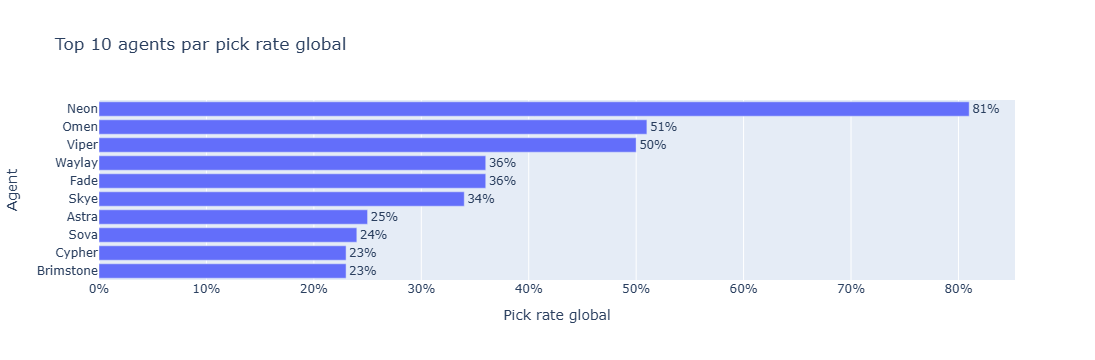

In [9]:
TOP_N = 10
top_global_agents = global_df.head(TOP_N)["agent"].tolist()

fig = px.bar(
    global_df.head(TOP_N),
    x="pick_rate",
    y="agent",
    orientation="h",
    text="pick_rate",
    title=f"Top {TOP_N} agents par pick rate global",
    labels={"pick_rate": "Pick rate global", "agent": "Agent"},
)
fig.update_traces(texttemplate="%{text:.0%}", textposition="outside")
fig.update_layout(yaxis={"categoryorder": "total ascending"}, xaxis_tickformat=".0%")
fig.show()

## 3. Heatmap des meilleurs agents par map

La heatmap permet de distinguer deux profils :

- agents **généralistes**, forts sur beaucoup de maps ;
- agents **spécialistes**, très forts sur quelques maps seulement.

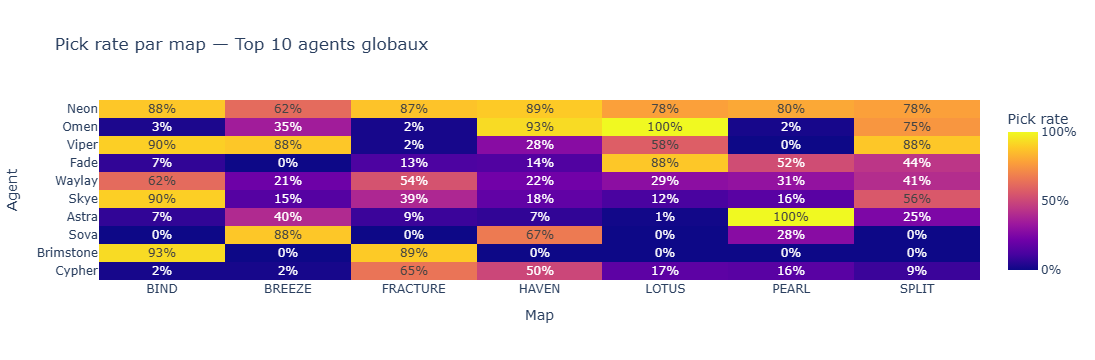

In [11]:
heatmap_df = (
    map_df[map_df["agent"].isin(top_global_agents)]
    .pivot_table(index="agent", columns="map", values="pick_rate", aggfunc="mean")
    .fillna(0)
)

# Garder l'ordre du classement global
heatmap_df = heatmap_df.reindex(top_global_agents)

fig = px.imshow(
    heatmap_df,
    text_auto=".0%",
    aspect="auto",
    title=f"Pick rate par map — Top {TOP_N} agents globaux",
    labels={"x": "Map", "y": "Agent", "color": "Pick rate"},
)
fig.update_coloraxes(colorbar_tickformat=".0%")
fig.show()

## 4. Profil de chaque meilleur agent

Pour chaque agent du top global, on affiche son pick rate par map. C'est la vue la plus utile pour expliquer si l'agent est un vrai pilier du méta ou seulement très fort dans certains contextes.

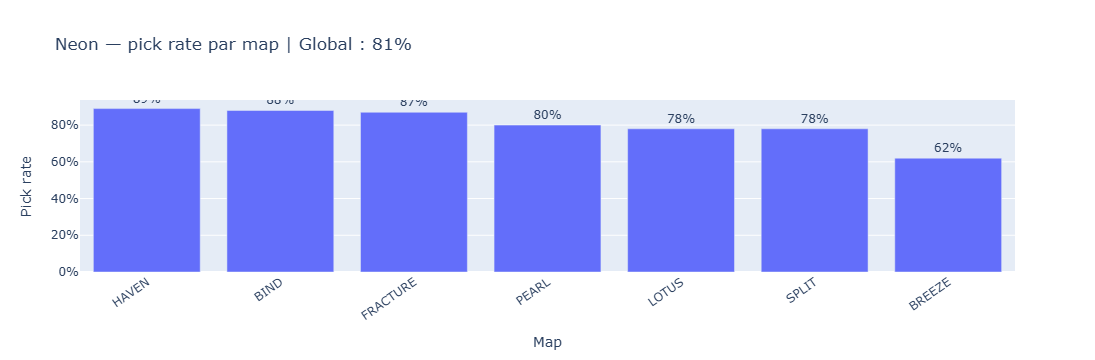

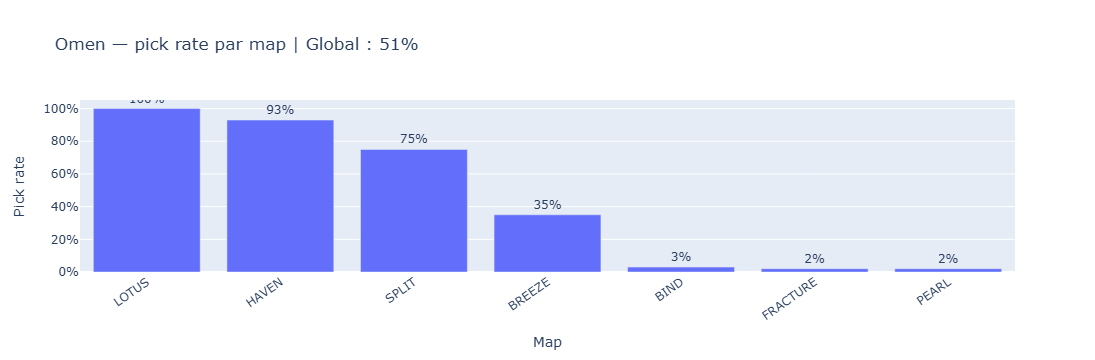

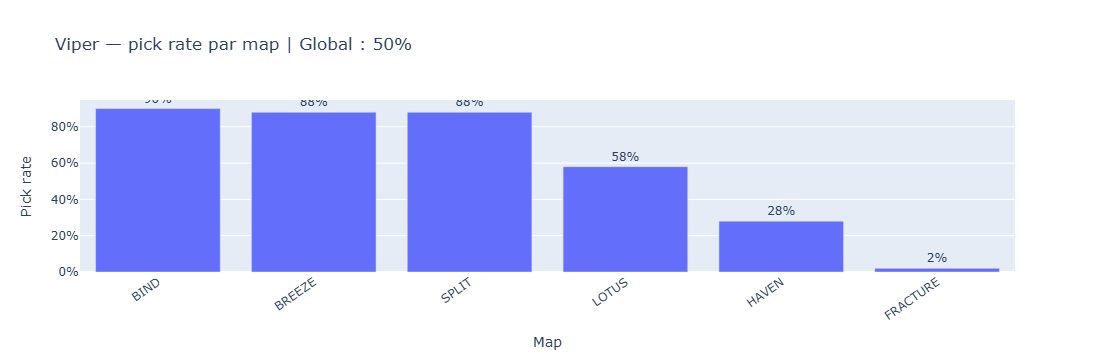

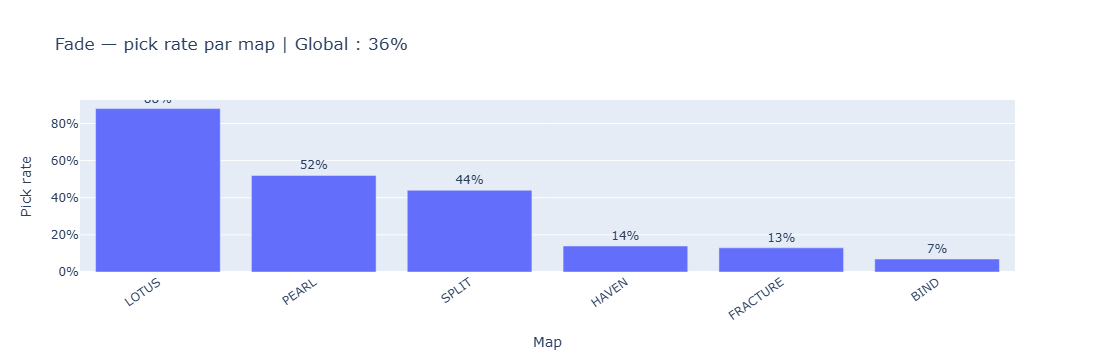

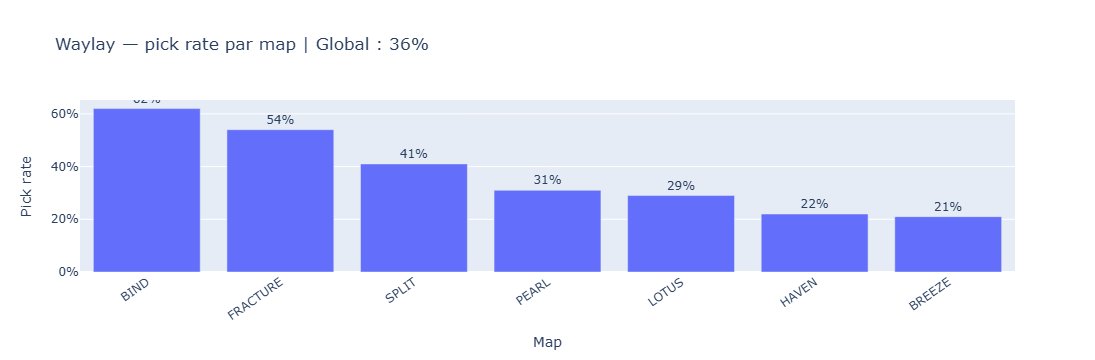

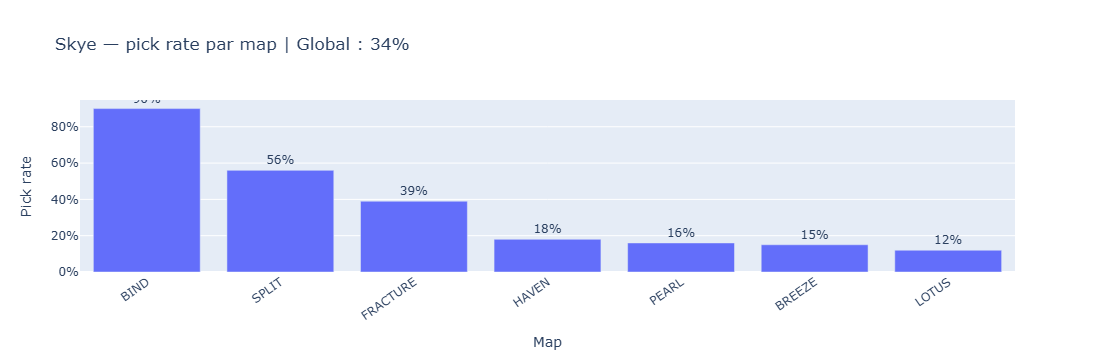

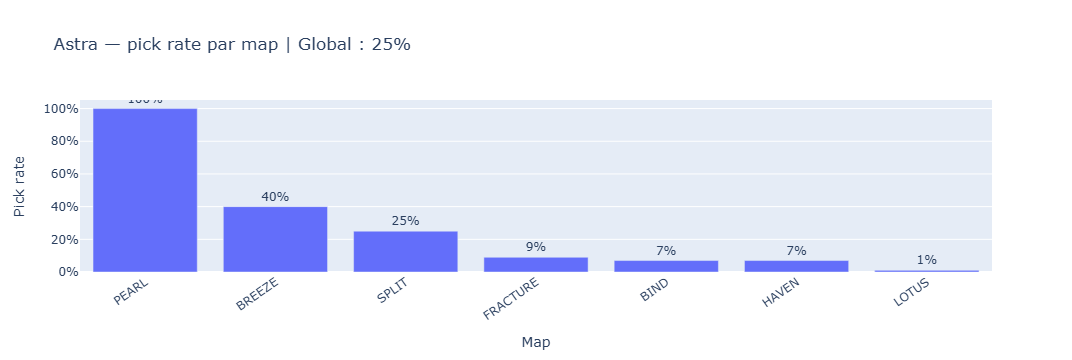

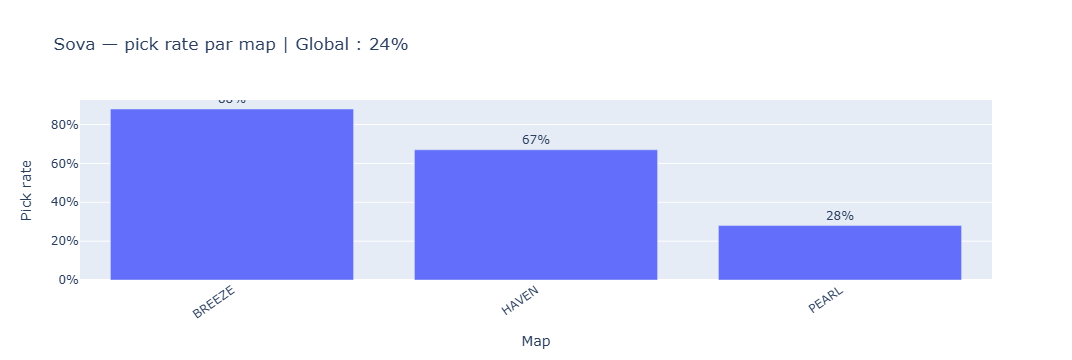

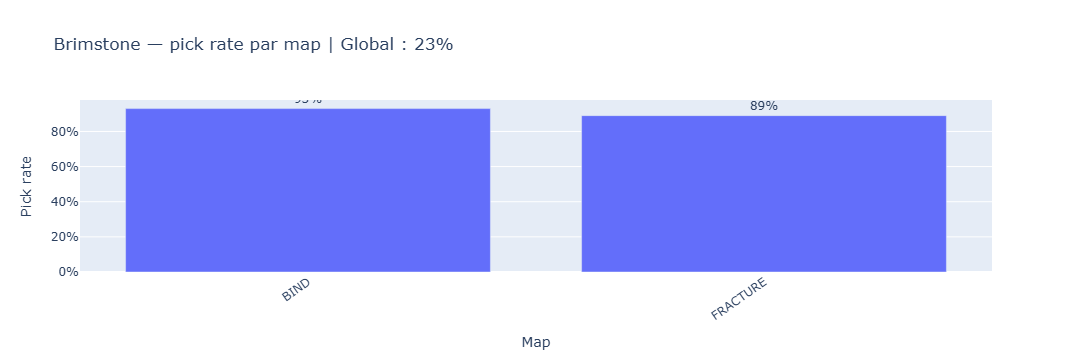

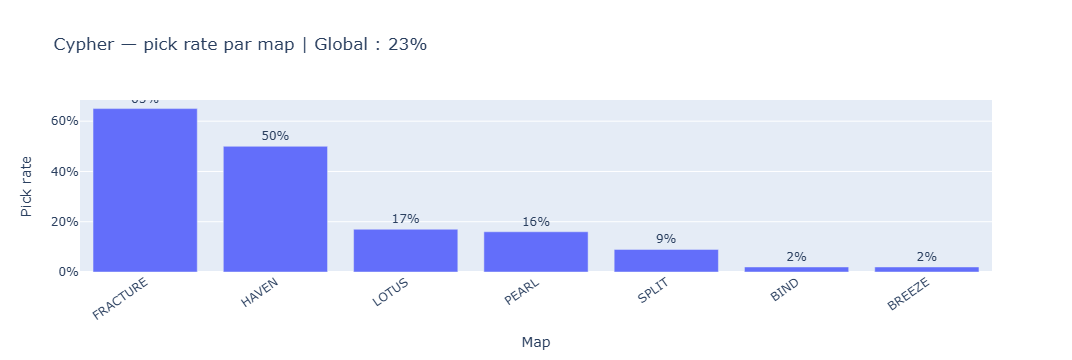

In [13]:
for agent in top_global_agents:
    agent_map = map_df[map_df["agent"].eq(agent)].sort_values("pick_rate", ascending=False)
    global_rate = global_df.loc[global_df["agent"].eq(agent), "pick_rate"].iloc[0]

    fig = px.bar(
        agent_map,
        x="map",
        y="pick_rate",
        text="pick_rate",
        title=f"{agent} — pick rate par map | Global : {global_rate:.0%}",
        labels={"map": "Map", "pick_rate": "Pick rate"},
    )
    fig.update_traces(texttemplate="%{text:.0%}", textposition="outside")
    fig.update_layout(xaxis_tickangle=-35, yaxis_tickformat=".0%")
    fig.show()

## 5. Mesures de stabilité, spécialisation et domination

On ajoute des métriques analytiques pour éviter une lecture trop superficielle du pick rate global.

In [15]:
agent_profile = (
    map_df.groupby("agent")
    .agg(
        avg_map_pick_rate=("pick_rate", "mean"),
        median_map_pick_rate=("pick_rate", "median"),
        max_map_pick_rate=("pick_rate", "max"),
        min_map_pick_rate=("pick_rate", "min"),
        std_map_pick_rate=("pick_rate", "std"),
        maps_played=("map", "nunique"),
    )
    .reset_index()
)

agent_profile = agent_profile.merge(
    global_df[["agent", "pick_rate", "agent_picks"]].rename(
        columns={"pick_rate": "global_pick_rate", "agent_picks": "global_picks"}
    ),
    on="agent",
    how="left",
)

agent_profile["range_map_pick_rate"] = agent_profile["max_map_pick_rate"] - agent_profile["min_map_pick_rate"]
agent_profile["stability_score"] = 1 - agent_profile["std_map_pick_rate"].fillna(0)
agent_profile["specialization_score"] = agent_profile["max_map_pick_rate"] - agent_profile["median_map_pick_rate"]

agent_profile = agent_profile.sort_values("global_pick_rate", ascending=False)
agent_profile.head(15)

,agent,avg_map_pick_rate,median_map_pick_rate,max_map_pick_rate,min_map_pick_rate,std_map_pick_rate,maps_played,global_pick_rate,global_picks,range_map_pick_rate,stability_score,specialization_score
14,Neon,0.802857,0.800,0.89,0.62,0.093580,7,0.81,372,0.27,0.906420,0.090
15,Omen,0.442857,0.350,1.00,0.02,0.443235,7,0.51,233,0.98,0.556765,0.650
23,Viper,0.590000,0.730,0.90,0.02,0.370243,6,0.50,230,0.88,0.629757,0.170
25,Waylay,0.371429,0.310,0.62,0.21,0.158685,7,0.36,167,0.41,0.841315,0.310
6,Fade,0.363333,0.290,0.88,0.07,0.312325,6,0.36,164,0.81,0.687675,0.590
19,Skye,0.351429,0.180,0.90,0.12,0.290427,7,0.34,155,0.78,0.709573,0.720
0,Astra,0.270000,0.090,1.00,0.01,0.348855,7,0.25,115,0.99,0.651145,0.910
20,Sova,0.610000,0.670,0.88,0.28,0.304467,3,0.24,111,0.60,0.695533,0.210
2,Brimstone,0.910000,0.910,0.93,0.89,0.028284,2,0.23,104,0.04,0.971716,0.020
4,Cypher,0.230000,0.160,0.65,0.02,0.246847,7,0.23,106,0.63,0.753153,0.490


## 6. Comparaison : popularité globale vs stabilité par map

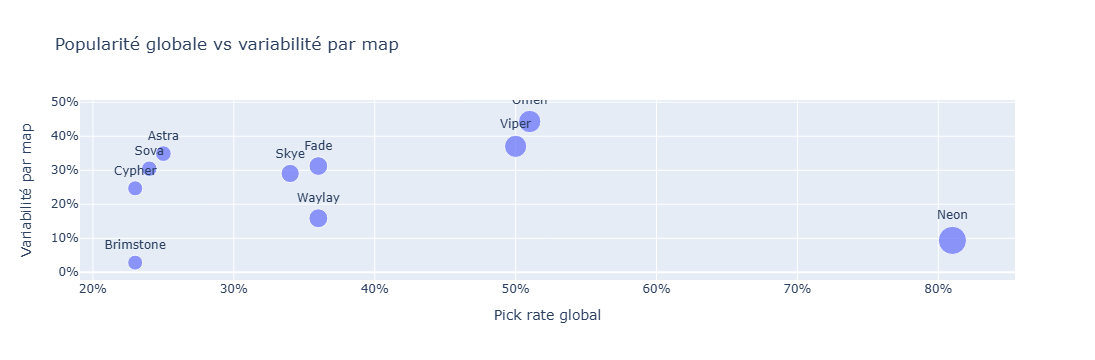

In [17]:
plot_df = agent_profile[agent_profile["agent"].isin(top_global_agents)].copy()

fig = px.scatter(
    plot_df,
    x="global_pick_rate",
    y="std_map_pick_rate",
    size="global_picks",
    text="agent",
    title="Popularité globale vs variabilité par map",
    labels={
        "global_pick_rate": "Pick rate global",
        "std_map_pick_rate": "Variabilité par map",
        "global_picks": "Picks globaux",
    },
)
fig.update_traces(textposition="top center")
fig.update_layout(xaxis_tickformat=".0%", yaxis_tickformat=".0%")
fig.show()

## 7. Top agents par map

Cette vue sert à comprendre le méta local de chaque map. Elle évite l'erreur classique : considérer qu'un agent fort globalement est automatiquement optimal partout.

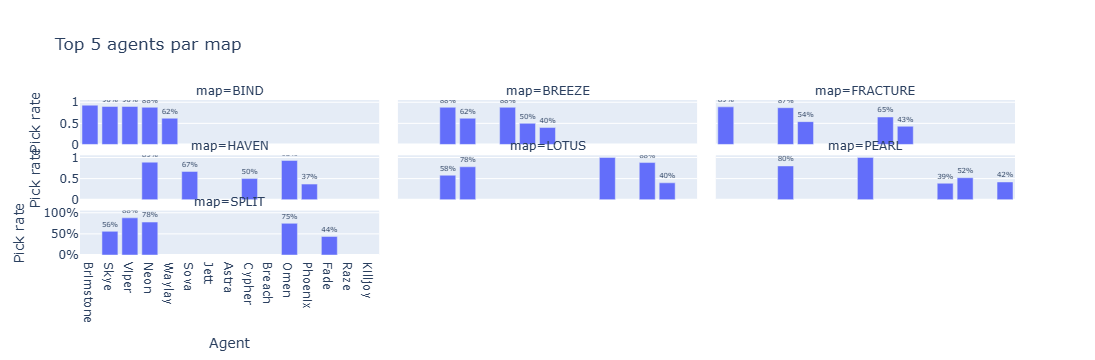

,map,agent,agent_picks,total_compositions,pick_rate
27,BIND,Brimstone,56,60,0.93
28,BIND,Skye,54,60,0.90
29,BIND,Viper,54,60,0.90
30,BIND,Neon,53,60,0.88
31,BIND,Waylay,37,60,0.62
47,BREEZE,Sova,42,48,0.88
48,BREEZE,Viper,42,48,0.88
49,BREEZE,Neon,30,48,0.62
50,BREEZE,Jett,24,48,0.50
51,BREEZE,Astra,19,48,0.40


In [19]:
TOP_PER_MAP = 5

top_by_map = (
    map_df.sort_values(["map", "pick_rate"], ascending=[True, False])
    .groupby("map")
    .head(TOP_PER_MAP)
    .copy()
)

fig = px.bar(
    top_by_map,
    x="agent",
    y="pick_rate",
    facet_col="map",
    facet_col_wrap=3,
    text="pick_rate",
    title=f"Top {TOP_PER_MAP} agents par map",
    labels={"agent": "Agent", "pick_rate": "Pick rate"},
)
fig.update_traces(texttemplate="%{text:.0%}", textposition="outside")
fig.update_layout(yaxis_tickformat=".0%")
fig.show()

top_by_map

## 8. Génération automatique d'insights

Les remarques ci-dessous sont générées à partir des métriques. Elles ne remplacent pas l'analyse métier, mais donnent une base solide pour commenter les visualisations.

In [21]:
def classify_agent(row: pd.Series) -> str:
    global_rate = row["global_pick_rate"]
    std = row["std_map_pick_rate"]
    specialization = row["specialization_score"]
    min_rate = row["min_map_pick_rate"]

    if global_rate >= 0.45 and std <= 0.18 and min_rate >= 0.20:
        return "Pilier global"
    if global_rate >= 0.35 and specialization >= 0.30:
        return "Spécialiste de certaines maps"
    if global_rate >= 0.30 and std > 0.22:
        return "Fort mais dépendant de la map"
    if global_rate >= 0.20:
        return "Option méta secondaire"
    return "Pick situationnel"


def generate_agent_insight(agent: str) -> str:
    row = agent_profile[agent_profile["agent"].eq(agent)].iloc[0]
    agent_map = map_df[map_df["agent"].eq(agent)].sort_values("pick_rate", ascending=False)

    best_map = agent_map.iloc[0]
    worst_map = agent_map.iloc[-1]
    above_50 = agent_map[agent_map["pick_rate"] >= 0.50]["map"].tolist()
    above_global = agent_map[agent_map["pick_rate"] >= row["global_pick_rate"]]["map"].tolist()

    category = classify_agent(row)

    reasons = []
    reasons.append(
        f"{agent} est classé comme **{category}** avec un pick rate global de {row['global_pick_rate']:.0%}."
    )
    reasons.append(
        f"Sa meilleure map est **{best_map['map']}** ({best_map['pick_rate']:.0%}) et sa map la plus faible est **{worst_map['map']}** ({worst_map['pick_rate']:.0%})."
    )
    reasons.append(
        f"La variabilité par map est de {row['std_map_pick_rate']:.0%}, ce qui indique {'une forte dépendance au contexte de map' if row['std_map_pick_rate'] > 0.22 else 'une présence plutôt stable selon les maps'}."
    )

    if above_50:
        reasons.append("Maps où l'agent dépasse 50% de présence : " + ", ".join(above_50) + ".")
    else:
        reasons.append("L'agent ne dépasse pas 50% sur une map précise : son intérêt est probablement plus contextuel ou réparti.")

    if len(above_global) <= 2:
        reasons.append("Son score global semble surtout tiré par quelques maps fortes, donc il faut éviter de le présenter comme un choix universel.")
    else:
        reasons.append("Son pick rate est supérieur ou égal à sa moyenne globale sur plusieurs maps, ce qui renforce son profil de choix fiable.")

    return "\n".join([f"- {r}" for r in reasons])

for agent in top_global_agents:
    print(f"\n## {agent}")
    print(generate_agent_insight(agent))


## Neon
- Neon est classé comme **Pilier global** avec un pick rate global de 81%.
- Sa meilleure map est **HAVEN** (89%) et sa map la plus faible est **BREEZE** (62%).
- La variabilité par map est de 9%, ce qui indique une présence plutôt stable selon les maps.
- Maps où l'agent dépasse 50% de présence : HAVEN, BIND, FRACTURE, PEARL, LOTUS, SPLIT, BREEZE.
- Son pick rate est supérieur ou égal à sa moyenne globale sur plusieurs maps, ce qui renforce son profil de choix fiable.

## Omen
- Omen est classé comme **Spécialiste de certaines maps** avec un pick rate global de 51%.
- Sa meilleure map est **LOTUS** (100%) et sa map la plus faible est **PEARL** (2%).
- La variabilité par map est de 44%, ce qui indique une forte dépendance au contexte de map.
- Maps où l'agent dépasse 50% de présence : LOTUS, HAVEN, SPLIT.
- Son pick rate est supérieur ou égal à sa moyenne globale sur plusieurs maps, ce qui renforce son profil de choix fiable.

## Viper
- Viper est classé comme **Fort mais dépe

## 9. Synthèse priorisée

Cette table est utile pour écrire une conclusion dans ton dashboard ou dans ton rapport.

In [23]:
summary = agent_profile[agent_profile["agent"].isin(top_global_agents)].copy()
summary["category"] = summary.apply(classify_agent, axis=1)
summary = summary[[
    "agent",
    "category",
    "global_pick_rate",
    "avg_map_pick_rate",
    "median_map_pick_rate",
    "max_map_pick_rate",
    "min_map_pick_rate",
    "std_map_pick_rate",
    "specialization_score",
    "global_picks",
]]

summary.sort_values(["global_pick_rate", "avg_map_pick_rate"], ascending=False)

,agent,category,global_pick_rate,avg_map_pick_rate,median_map_pick_rate,max_map_pick_rate,min_map_pick_rate,std_map_pick_rate,specialization_score,global_picks
14,Neon,Pilier global,0.81,0.802857,0.80,0.89,0.62,0.093580,0.09,372
15,Omen,Spécialiste de certaines maps,0.51,0.442857,0.35,1.00,0.02,0.443235,0.65,233
23,Viper,Fort mais dépendant de la map,0.50,0.590000,0.73,0.90,0.02,0.370243,0.17,230
25,Waylay,Spécialiste de certaines maps,0.36,0.371429,0.31,0.62,0.21,0.158685,0.31,167
6,Fade,Spécialiste de certaines maps,0.36,0.363333,0.29,0.88,0.07,0.312325,0.59,164
19,Skye,Fort mais dépendant de la map,0.34,0.351429,0.18,0.90,0.12,0.290427,0.72,155
0,Astra,Option méta secondaire,0.25,0.270000,0.09,1.00,0.01,0.348855,0.91,115
20,Sova,Option méta secondaire,0.24,0.610000,0.67,0.88,0.28,0.304467,0.21,111
2,Brimstone,Option méta secondaire,0.23,0.910000,0.91,0.93,0.89,0.028284,0.02,104
4,Cypher,Option méta secondaire,0.23,0.230000,0.16,0.65,0.02,0.246847,0.49,106


## 10. Conclusion analytique à adapter

À partir de ces résultats, il faut éviter une conclusion du type “les meilleurs agents sont seulement ceux avec le plus gros pick rate global”. Une meilleure lecture consiste à distinguer :

1. les **piliers globaux**, présents sur beaucoup de maps ;
2. les **spécialistes de map**, très forts dans certains contextes ;
3. les **picks situationnels**, moins dominants mais potentiellement intéressants pour des compositions originales ou anti-méta.

Pour un dashboard compétitif, la meilleure approche est donc de combiner le pick rate global avec la stabilité par map et le niveau de spécialisation.